In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [6]:
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score

In [7]:
housing=fetch_california_housing()
data=pd.DataFrame(housing.data,
columns=housing.feature_names)
data["Price"]=housing.target

In [8]:
X = data[['AveRooms']].values
y = data['Price'].values

In [9]:
X_train,X_test,y_train,y_test = train_test_split(
    X,y,
    test_size = 0.2,
    random_state = 42
)

In [10]:
scaler=StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [17]:
w = 0
b = 0

learning_rate = 0.01
epochs = 1000

n = len(X_train_scaled)
cost_history = []

for i in range(epochs):
    y_pred = w * X_train_scaled.flatten() + b

    dw = (1/n) * np.sum((y_pred - y_train) * X_train_scaled.flatten())
    db = (1/n) * np.sum(y_pred - y_train)

    w = w - learning_rate * dw
    b = b - learning_rate * db

 
    cost = (1/(2*n)) * np.sum((y_pred - y_train)**2)
    cost_history.append(cost)

    if i % 100 == 0:
        print(f"Epoch {i}, Cost = {cost:.4f}")
y_pred_gd = w * X_test_scaled.flatten() + b


Epoch 0, Cost = 2.8149
Epoch 100, Cost = 0.9414
Epoch 200, Cost = 0.6904
Epoch 300, Cost = 0.6568
Epoch 400, Cost = 0.6523
Epoch 500, Cost = 0.6517
Epoch 600, Cost = 0.6516
Epoch 700, Cost = 0.6516
Epoch 800, Cost = 0.6516
Epoch 900, Cost = 0.6516


In [18]:
print("Gradient Descent")
print("---------------------------")
print("Weight:", w)
print("Bias:" ,b)
print("MSe:", mean_squared_error(y_test,y_pred_gd))
print("R2 Score:",r2_score(y_test,y_pred_gd))

Gradient Descent
---------------------------
Weight: 0.18323090648660517
Bias: 2.0718574888450205
MSe: 1.292327655590046
R2 Score: 0.013798228607320828


In [19]:
X_train_ne = np.c_[np.ones((len(X_train),1)), X_train]
X_test_ne=np.c_[np.ones((len(X_test),1)), X_test]
theta = np.linalg.inv(X_train_ne.T @ X_train_ne) @ X_train_ne.T @ y_train
y_pred_ne = X_test_ne @ theta

In [20]:
print("\nNormal Equation")
print("------------------")
print("Intercept:", theta[0])
print("Slpoe:", theta[1])
print("MSE:" , mean_squared_error(y_test,y_pred_ne))
print("R2 Score:",r2_score(y_test,y_pred_ne))
      


Normal Equation
------------------
Intercept: 1.6547622685968417
Slpoe: 0.07675558963126736
MSE: 1.2923314440807299
R2 Score: 0.013795337532284901


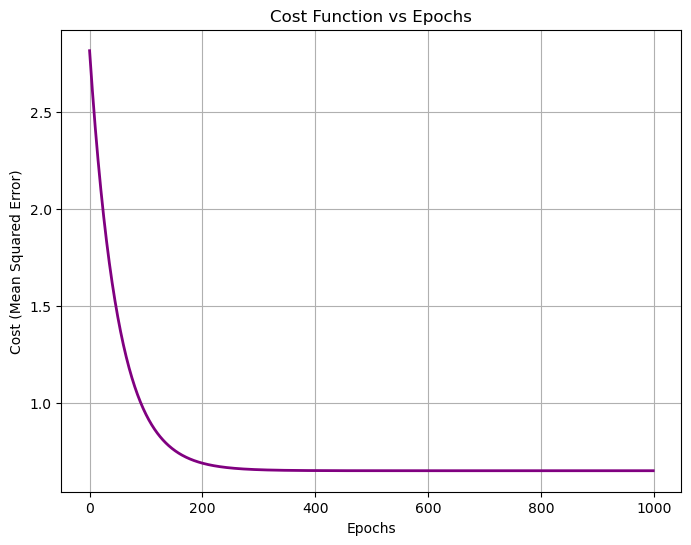

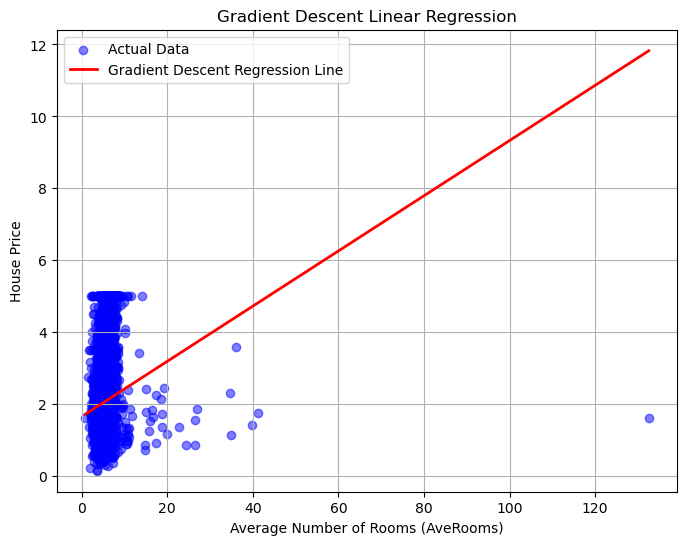

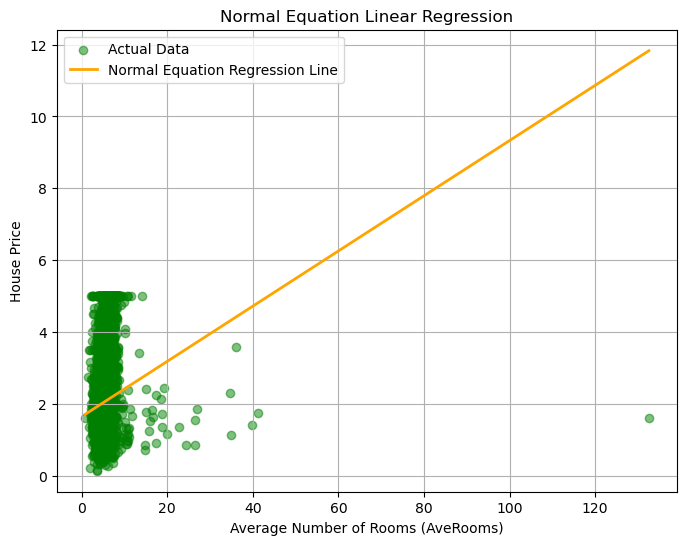

In [21]:
plt.figure(figsize=(8,6))

plt.plot(range(epochs), cost_history, color='purple', linewidth=2)

plt.title("Cost Function vs Epochs")
plt.xlabel("Epochs")
plt.ylabel("Cost (Mean Squared Error)")
plt.grid(True)

plt.show()
plt.figure(figsize=(8,6))


plt.scatter(X_test, y_test, color='blue', alpha=0.5, label='Actual Data')


sorted_idx = np.argsort(X_test.flatten())
plt.plot(X_test.flatten()[sorted_idx],
         y_pred_gd[sorted_idx],
         color='red',
         linewidth=2,
         label='Gradient Descent Regression Line')

plt.title("Gradient Descent Linear Regression")
plt.xlabel("Average Number of Rooms (AveRooms)")
plt.ylabel("House Price")
plt.legend()
plt.grid(True)
plt.show()



plt.figure(figsize=(8,6))


plt.scatter(X_test, y_test, color='green', alpha=0.5, label='Actual Data')


plt.plot(X_test.flatten()[sorted_idx],
         y_pred_ne[sorted_idx],
         color='orange',
         linewidth=2,
         label='Normal Equation Regression Line')

plt.title("Normal Equation Linear Regression")
plt.xlabel("Average Number of Rooms (AveRooms)")
plt.ylabel("House Price")
plt.legend()
plt.grid(True)
plt.show()
